# Import Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from warnings import filterwarnings
import seaborn as sns
filterwarnings("ignore")

# Import Data

In [2]:
df=pd.read_spss("BDHS_2017-2018.sav")

# Get some Basic Information

In [3]:
df.head()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190A,V113,V116,V161,V213,V404,V743A,V312,V501,BMI2
0,15-19,Rajshahi,Rural,Secondary,No education,Islam,Male,No child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married,Underweight/Normal
1,45-49,Rangpur,Urban,Primary,No education,Islam,Male,More than two child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Traditional methods,Married,Underweight/Normal
2,15-19,Khulna,Rural,Secondary,Primary,Islam,Male,One child,No,No,...,Poorer,Improved,Improved,Solid fuel,No or unsure,Yes,Respondent and husband/partner,Modern methods,Married,Underweight/Normal
3,40-44,Barisal,Urban,Primary,Primary,Islam,Male,More than two child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Not using,Married,Underweight/Normal
4,25-29,Barisal,Rural,Secondary,Higher,Islam,Male,One child,No,No,...,Richest,Improved,Improved,Solid fuel,Yes,No,Respondent and husband/partner,Not using,Married,Underweight/Normal


In [4]:
df.shape

(16303, 28)

In [5]:
df.columns

Index(['V013', 'V024', 'V025', 'V106', 'V701', 'V130', 'V151', 'V201', 'V123',
       'V124', 'V125', 'V119', 'V122', 'V121', 'V159', 'V716', 'V704', 'V190',
       'V190A', 'V113', 'V116', 'V161', 'V213', 'V404', 'V743A', 'V312',
       'V501', 'BMI2'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16303 entries, 0 to 16302
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   V013    16303 non-null  category
 1   V024    16303 non-null  category
 2   V025    16303 non-null  category
 3   V106    16303 non-null  category
 4   V701    16303 non-null  category
 5   V130    16303 non-null  category
 6   V151    16303 non-null  category
 7   V201    16303 non-null  category
 8   V123    16303 non-null  category
 9   V124    16303 non-null  category
 10  V125    16303 non-null  category
 11  V119    16303 non-null  category
 12  V122    16303 non-null  category
 13  V121    16303 non-null  category
 14  V159    16303 non-null  category
 15  V716    16303 non-null  category
 16  V704    16303 non-null  category
 17  V190    16303 non-null  category
 18  V190A   16303 non-null  category
 19  V113    16303 non-null  category
 20  V116    16303 non-null  category
 21  V161    1630

In [7]:
df.describe()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190A,V113,V116,V161,V213,V404,V743A,V312,V501,BMI2
count,16303,16303,16303,16303,16303,16303,16303,16303,16303,16303,...,16303,16303,16303,16303,16303,16303,16303,16303,16303,16303
unique,7,8,2,4,5,4,2,4,2,2,...,5,2,2,2,2,2,3,3,1,2
top,30-34,Chittagong,Rural,Secondary,Primary,Islam,Male,More than two child,No,No,...,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married,Underweight/Normal
freq,2939,2294,10763,6302,5262,14647,14453,6930,11327,14709,...,3469,16000,11004,13219,15428,12960,13997,8680,16303,10951


In [8]:
df.isna().sum().sum(), df.isnull().sum().sum()

(0, 0)

In [9]:
df.BMI2.value_counts()

BMI2
Underweight/Normal    10951
Overweight/Obese       5352
Name: count, dtype: int64

In [10]:
BMI_2=df.BMI2.value_counts().index

In [11]:
BMI_2_Val=df.BMI2.value_counts().values

In [12]:
x=df[['V013', 'V024', 'V025', 'V106', 'V701', 'V130', 'V151', 'V201',
       'V123', 'V124', 'V125', 'V119', 'V122', 'V121','V159','V716', 'V704', 'V190', 'V190A', 'V113', 'V116', 'V161', 'V213', 'V404',
       'V743A', 'V312', 'V501']]

In [13]:
x

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,15-19,Rajshahi,Rural,Secondary,No education,Islam,Male,No child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
1,45-49,Rangpur,Urban,Primary,No education,Islam,Male,More than two child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Traditional methods,Married
2,15-19,Khulna,Rural,Secondary,Primary,Islam,Male,One child,No,No,...,Poorer,Poorer,Improved,Improved,Solid fuel,No or unsure,Yes,Respondent and husband/partner,Modern methods,Married
3,40-44,Barisal,Urban,Primary,Primary,Islam,Male,More than two child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Not using,Married
4,25-29,Barisal,Rural,Secondary,Higher,Islam,Male,One child,No,No,...,Richer,Richest,Improved,Improved,Solid fuel,Yes,No,Respondent and husband/partner,Not using,Married
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16298,30-34,Dhaka,Urban,Higher,Higher,Islam,Male,More than two child,Yes,Yes,...,Richest,Richer,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
16299,30-34,Rajshahi,Urban,No education,No education,Islam,Male,Two child,Yes,Yes,...,Richest,Richer,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
16300,25-29,Dhaka,Urban,Higher,Higher,Islam,Male,More than two child,Yes,Yes,...,Richest,Richer,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Married
16301,20-24,Dhaka,Urban,Secondary,Secondary,Islam,Male,Two child,No,No,...,Richest,Richest,Improved,Unimproved,Clean fuel,No or unsure,No,Respondent alone,Modern methods,Married


In [14]:
x['V013']=x['V013'].map({'15-19': 1, '20-24': 2, '25-29': 3 ,'30-34': 4, '35-39':5, '40-44':6, '45-49':7})

In [15]:
x['V024']=x['V024'].map({'Barisal': 1, 'Chittagong': 2,'Dhaka':3, 'Khulna':4, 'Mymensingh':5, 'Rajshahi':6, 'Rangpur':7, 'Sylhet':8})

In [16]:
x['V025']= x['V025'].map({'Urban':1, 'Rural': 2})

In [17]:
x['V106']= x['V106'].map({'No education':0, 'Primary': 1, 'Secondary':2, 'Higher':3})

In [18]:
x['V701']= x['V701'].map({'No education':0, 'Primary': 1, 'Secondary':2, 'Higher':3, "Don't know":4})

In [19]:
x['V130']= x['V130'].map({'Islam':0, 'Hinduism': 1, 'Buddhism':2, 'Christianity':3})

In [20]:
x['V151']= x['V151'].map({'Male':1, 'Female': 2})

In [21]:
x['V201']= x['V201'].map({'No child':0, 'One child': 1, 'Two child':2, 'More than two child':3})

In [22]:
x['V123']= x['V123'].map({'No':0, 'Yes': 1})

In [23]:
x['V124']= x['V124'].map({'No':0, 'Yes': 1})

In [24]:
x['V119']= x['V119'].map({'No':0, 'Yes': 1})

In [25]:
x['V122']= x['V122'].map({'No':0, 'Yes': 1})

In [26]:
x['V121']= x['V121'].map({'No':0, 'Yes': 1})

In [27]:
x['V159']= x['V159'].map({'Not at all':0, 'Less than once a week': 1, 'At least once a week':2, 'Almost every day':3})

In [28]:
x['V716']= x['V716'].map({'Unemployed':0, 'Agriculture': 1, 'Business':2, 'Labor/Service':3, 'Job':4})

In [29]:
x['V704']= x['V704'].map({'Unemployed':0, 'Agriculture': 1, 'Business':2, 'Labor/Service':3, 'Job':4})

In [30]:
x['V190']= x['V190'].map({'Poorest':1, 'Poorer': 2, 'Middle':3, 'Richer':4, 'Richest':5})

In [31]:
x['V190A']= x['V190A'].map({'Poorest':1, 'Poorer': 2, 'Middle':3, 'Richer':4, 'Richest':5})

In [32]:
x['V113']= x['V113'].map({'Improved':1, 'Unimproved': 2})

In [33]:
x['V116']= x['V116'].map({'Improved':1, 'Unimproved': 2})

In [34]:
x['V161']= x['V161'].map({'Solid fuel':0, 'Clean fuel': 1})

In [35]:
x['V213']= x['V213'].map({'No or unsure':0, 'Yes': 1})

In [36]:
x['V404']= x['V404'].map({'No':0, 'Yes': 1})

In [37]:
x['V743A']= x['V743A'].map({'Respondent alone':1, 'Respondent and husband/partner': 2, "Respondent and other's person":3})

In [38]:
x['V312']= x['V312'].map({'Not using':0, 'Modern methods': 1, 'Traditional methods':2})

In [39]:
x['V501']= x['V501'].map({'Married':1, 'Widowed': 2, 'Divorced/Separated':3})

In [40]:
x

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,1,6,2,2,0,0,1,0,0,0,...,1,1,1,1,0,0,0,2,1,1
1,7,7,1,1,0,0,1,3,0,0,...,1,1,1,1,0,0,0,2,2,1
2,1,4,2,2,1,0,1,1,0,0,...,2,2,1,1,0,0,1,2,1,1
3,6,1,1,1,1,0,1,3,0,0,...,1,1,1,1,0,0,0,2,0,1
4,3,1,2,2,3,0,1,1,0,0,...,4,5,1,1,0,1,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16298,4,3,1,3,3,0,1,3,1,1,...,5,4,1,2,1,0,0,2,1,1
16299,4,6,1,0,0,0,1,2,1,1,...,5,4,1,2,1,0,0,2,1,1
16300,3,3,1,3,3,0,1,3,1,1,...,5,4,1,2,1,0,0,2,1,1
16301,2,3,1,2,2,0,1,2,0,0,...,5,5,1,2,1,0,0,1,1,1


In [41]:
x.head()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,1,6,2,2,0,0,1,0,0,0,...,1,1,1,1,0,0,0,2,1,1
1,7,7,1,1,0,0,1,3,0,0,...,1,1,1,1,0,0,0,2,2,1
2,1,4,2,2,1,0,1,1,0,0,...,2,2,1,1,0,0,1,2,1,1
3,6,1,1,1,1,0,1,3,0,0,...,1,1,1,1,0,0,0,2,0,1
4,3,1,2,2,3,0,1,1,0,0,...,4,5,1,1,0,1,0,2,0,1


In [42]:
y= df['BMI2']= df['BMI2'].map({'Underweight/Normal':0, 'Overweight/Obese': 1})

In [43]:
y

0        0
1        0
2        0
3        0
4        0
        ..
16298    0
16299    1
16300    1
16301    1
16302    1
Name: BMI2, Length: 16303, dtype: category
Categories (2, int64): [1, 0]

# Dataset Scalling

In [44]:
from sklearn.preprocessing import MinMaxScaler

In [45]:
scaler= MinMaxScaler()

In [46]:
scaled_X = scaler.fit_transform(x)

ValueError: could not convert string to float: 'No'

In [47]:
x=scaled_df

NameError: name 'scaled_df' is not defined

In [48]:
x

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,1,6,2,2,0,0,1,0,0,0,...,1,1,1,1,0,0,0,2,1,1
1,7,7,1,1,0,0,1,3,0,0,...,1,1,1,1,0,0,0,2,2,1
2,1,4,2,2,1,0,1,1,0,0,...,2,2,1,1,0,0,1,2,1,1
3,6,1,1,1,1,0,1,3,0,0,...,1,1,1,1,0,0,0,2,0,1
4,3,1,2,2,3,0,1,1,0,0,...,4,5,1,1,0,1,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16298,4,3,1,3,3,0,1,3,1,1,...,5,4,1,2,1,0,0,2,1,1
16299,4,6,1,0,0,0,1,2,1,1,...,5,4,1,2,1,0,0,2,1,1
16300,3,3,1,3,3,0,1,3,1,1,...,5,4,1,2,1,0,0,2,1,1
16301,2,3,1,2,2,0,1,2,0,0,...,5,5,1,2,1,0,0,1,1,1


In [49]:
y

0        0
1        0
2        0
3        0
4        0
        ..
16298    0
16299    1
16300    1
16301    1
16302    1
Name: BMI2, Length: 16303, dtype: category
Categories (2, int64): [1, 0]

In [50]:
x=pd.DataFrame(x)

In [51]:
x

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,V501
0,1,6,2,2,0,0,1,0,0,0,...,1,1,1,1,0,0,0,2,1,1
1,7,7,1,1,0,0,1,3,0,0,...,1,1,1,1,0,0,0,2,2,1
2,1,4,2,2,1,0,1,1,0,0,...,2,2,1,1,0,0,1,2,1,1
3,6,1,1,1,1,0,1,3,0,0,...,1,1,1,1,0,0,0,2,0,1
4,3,1,2,2,3,0,1,1,0,0,...,4,5,1,1,0,1,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16298,4,3,1,3,3,0,1,3,1,1,...,5,4,1,2,1,0,0,2,1,1
16299,4,6,1,0,0,0,1,2,1,1,...,5,4,1,2,1,0,0,2,1,1
16300,3,3,1,3,3,0,1,3,1,1,...,5,4,1,2,1,0,0,2,1,1
16301,2,3,1,2,2,0,1,2,0,0,...,5,5,1,2,1,0,0,1,1,1


# Lasso Feature Selection

In [137]:
from sklearn.linear_model import Lasso, LogisticRegression

In [138]:
from sklearn.preprocessing import StandardScaler

In [139]:
from sklearn.feature_selection import SelectFromModel

In [140]:
from sklearn.model_selection import GridSearchCV

In [141]:
from sklearn.pipeline import Pipeline

In [142]:
from sklearn.linear_model import LassoCV

In [143]:
lasso_model = Lasso(alpha=0.01) 

In [144]:
lasso_model.fit(x, y)

ValueError: could not convert string to float: 'No'

In [145]:
feature_coefs = lasso_model.coef_

AttributeError: 'Lasso' object has no attribute 'coef_'

In [61]:
coefficients_df = pd.DataFrame({
    'Feature': x.columns,
    'Lasso Coefficient': feature_coefs
})

print(coefficients_df)

NameError: name 'feature_coefs' is not defined

In [76]:
important_features = x.columns[feature_coefs != 0]

NameError: name 'feature_coefs' is not defined

In [39]:
important_features

Index([0, 2, 12, 13, 17, 20, 21, 23], dtype='int64')

In [40]:
feature_names = df.columns.tolist()[:-1] 

In [41]:
feature_names

['V013',
 'V024',
 'V025',
 'V106',
 'V701',
 'V130',
 'V151',
 'V201',
 'V123',
 'V124',
 'V125',
 'V119',
 'V122',
 'V121',
 'V159',
 'V716',
 'V704',
 'V190',
 'V190A',
 'V113',
 'V116',
 'V161',
 'V213',
 'V404',
 'V743A',
 'V312',
 'V501']

In [43]:
selected_indices = [0, 2, 12, 13, 17, 20, 21, 23]

In [44]:
selected_features = [feature_names[i] for i in selected_indices]

In [45]:
print("Selected Feature Names: ", selected_features)

Selected Feature Names:  ['V013', 'V025', 'V122', 'V121', 'V190', 'V116', 'V161', 'V404']


In [46]:
new_data_x = x[important_features]

In [47]:
x_new = new_data_x

In [48]:
y_new = y

In [49]:
new_data = x_new, y_new

In [50]:
new_data

(             0    2    12   13    17   20   21   23
 0      0.000000  1.0  0.0  0.0  0.00  0.0  0.0  0.0
 1      1.000000  0.0  0.0  0.0  0.00  0.0  0.0  0.0
 2      0.000000  1.0  0.0  0.0  0.25  0.0  0.0  1.0
 3      0.833333  0.0  0.0  0.0  0.00  0.0  0.0  0.0
 4      0.333333  1.0  0.0  0.0  0.75  0.0  0.0  0.0
 ...         ...  ...  ...  ...   ...  ...  ...  ...
 16298  0.500000  0.0  1.0  1.0  1.00  1.0  1.0  0.0
 16299  0.500000  0.0  1.0  1.0  1.00  1.0  1.0  0.0
 16300  0.333333  0.0  1.0  1.0  1.00  1.0  1.0  0.0
 16301  0.166667  0.0  1.0  1.0  1.00  1.0  1.0  0.0
 16302  0.833333  0.0  1.0  1.0  1.00  1.0  1.0  0.0
 
 [16303 rows x 8 columns],
 0        0
 1        0
 2        0
 3        0
 4        0
         ..
 16298    0
 16299    1
 16300    1
 16301    1
 16302    1
 Name: BMI2, Length: 16303, dtype: int64)

# Using SMOTE-EEN

In [51]:
from imblearn.combine import SMOTEENN

In [52]:
smote_enn = SMOTEENN()
x_resampled, y_resampled = smote_enn.fit_resample(x_new, y_new)
y_resampled.value_counts()

BMI2
0    7049
1     866
Name: count, dtype: int64

# Train - Test Split

In [53]:
from sklearn.model_selection import train_test_split
x_new_train, x_new_test, y_new_train, y_new_test = train_test_split(x_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42)

In [54]:
x_new_train.shape, x_new_test.shape

((6332, 8), (1583, 8))

In [55]:
y_new_train.shape, y_new_test.shape

((6332,), (1583,))

# Default Model selection 

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.model_selection import KFold, RandomizedSearchCV , GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

# SVM

In [57]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [59]:
model_svm=SVC()
model_svm.fit(x_new_train, y_new_train) 
y_pred = model_svm.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1410
           1       0.92      0.77      0.84       173

    accuracy                           0.97      1583
   macro avg       0.95      0.88      0.91      1583
weighted avg       0.97      0.97      0.97      1583



In [60]:
print(accuracy_score(y_new_test,model_svm.predict(x_new_test)))

0.9684144030322173


In [61]:
print(accuracy_score(y_new_train,model_svm.predict(x_new_train)))

0.9740998104864181


In [62]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [63]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [64]:
accuracy

0.9684144030322173

In [65]:
precision

0.948508464821831

In [66]:
f1

0.9126055579111017

In [67]:
kappa

0.8253622932589625

In [68]:
specificity

0.9921985815602837

In [69]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.8833825277743614


# Random forest

In [70]:
model_rfc=RandomForestClassifier()
model_rfc.fit(x_new_train, y_new_train) 
y_pred = model_rfc.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1410
           1       0.99      0.95      0.97       173

    accuracy                           0.99      1583
   macro avg       0.99      0.98      0.98      1583
weighted avg       0.99      0.99      0.99      1583



In [71]:
print(accuracy_score(y_new_test,model_rfc.predict(x_new_test)))

0.9936828806064435


In [72]:
print(accuracy_score(y_new_train,model_rfc.predict(x_new_train)))

1.0


In [73]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [74]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [75]:
accuracy

0.9936828806064435

In [76]:
precision

0.9911871172908421

In [77]:
f1

0.9835248324382831

In [78]:
kappa

0.9670508993876421

In [79]:
specificity

0.9985815602836879

In [80]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9761693928586069


# Logistic Regression

In [81]:
model_logit=LogisticRegression()
model_logit.fit(x_new_train, y_new_train) 
y_pred = model_logit.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1410
           1       0.75      0.50      0.60       173

    accuracy                           0.93      1583
   macro avg       0.85      0.74      0.78      1583
weighted avg       0.92      0.93      0.92      1583



In [82]:
print(accuracy_score(y_new_test,model_logit.predict(x_new_test)))

0.9273531269740998


In [83]:
print(accuracy_score(y_new_train,model_logit.predict(x_new_train)))

0.930511686670878


In [84]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [85]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [86]:
accuracy

0.9273531269740998

In [87]:
precision

0.8456884798909339

In [88]:
recall

0.7411613987619399

In [89]:
f1

0.7810519656553047

In [90]:
kappa

0.5638084010820628

In [91]:
specificity

0.9794326241134752

In [92]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.7411613987619399


# Naive Bayes

In [93]:
model_mnb=MultinomialNB()
model_mnb.fit(x_new_train, y_new_train) 
y_pred = model_mnb.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1410
           1       0.52      0.33      0.40       173

    accuracy                           0.89      1583
   macro avg       0.72      0.65      0.67      1583
weighted avg       0.88      0.89      0.88      1583



In [94]:
print(accuracy_score(y_new_test,model_mnb.predict(x_new_test)))

0.8938723941882502


In [95]:
print(accuracy_score(y_new_train,model_mnb.predict(x_new_train)))

0.9042956411876184


In [96]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [97]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [98]:
accuracy

0.8938723941882502

In [99]:
precision

0.7221191789177548

In [100]:
recall

0.6463001680810068

In [101]:
f1

0.6730014459822351

In [102]:
kappa

0.349280142503401

In [103]:
specificity

0.9631205673758865

In [104]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.6463001680810069


In [105]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.6463001680810069


# KNN

In [106]:
model_knn=KNeighborsClassifier()
model_knn.fit(x_new_train, y_new_train) 
y_pred = model_knn.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1410
           1       0.94      0.87      0.90       173

    accuracy                           0.98      1583
   macro avg       0.96      0.93      0.95      1583
weighted avg       0.98      0.98      0.98      1583



In [107]:
print(accuracy_score(y_new_test,model_knn.predict(x_new_test)))

0.9797852179406191


In [108]:
print(accuracy_score(y_new_train,model_knn.predict(x_new_train)))

0.9921036007580544


In [109]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [110]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [111]:
accuracy

0.9797852179406191

In [112]:
precision

0.963622270510918

In [113]:
recall

0.9303345221989916

In [114]:
f1

0.9461614984992901

In [115]:
kappa

0.8923454229378036

In [116]:
specificity

0.9936170212765958

In [117]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9303345221989915


# Decision Tree

In [118]:
model_dt= tree.DecisionTreeClassifier()
model_dt.fit(x_new_train, y_new_train) 
y_pred = model_dt.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1410
           1       0.96      0.95      0.96       173

    accuracy                           0.99      1583
   macro avg       0.98      0.97      0.98      1583
weighted avg       0.99      0.99      0.99      1583



In [119]:
print(accuracy_score(y_new_test,model_dt.predict(x_new_test)))

0.9905243209096652


In [120]:
print(accuracy_score(y_new_train,model_dt.predict(x_new_train)))

1.0


In [121]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [122]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [123]:
accuracy

0.9905243209096652

In [124]:
precision

0.9768162939033838

In [125]:
recall

0.974396343213217

In [126]:
f1

0.9756022378743276

In [127]:
kappa

0.9512045258855418

In [128]:
specificity

0.9950354609929078

In [129]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.974396343213217


# ANN

In [130]:
from sklearn.neural_network import MLPClassifier
model_ann = MLPClassifier()
model_ann.fit(x_new_train, y_new_train) 
y_pred = model_ann.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1410
           1       0.93      0.85      0.89       173

    accuracy                           0.98      1583
   macro avg       0.96      0.92      0.94      1583
weighted avg       0.98      0.98      0.98      1583



In [131]:
print(accuracy_score(y_new_test,model_ann.predict(x_new_test)))

0.9766266582438408


In [132]:
print(accuracy_score(y_new_train,model_ann.predict(x_new_train)))

0.9831017056222363


In [133]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [134]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [135]:
accuracy

0.9766266582438408

In [136]:
precision

0.9560670664001776

In [137]:
recall

0.9209547821096216

In [138]:
f1

0.9375831881370653

In [139]:
kappa

0.8751963009130523

In [140]:
specificity

0.9921985815602837

In [141]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9209547821096217


# XGBoost

In [142]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from xgboost import XGBClassifier

In [143]:
model_xg = XGBClassifier()

In [144]:
model_xg.fit(x_new_train, y_new_train) 
y_pred = model_xg.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1410
           1       0.98      0.95      0.96       173

    accuracy                           0.99      1583
   macro avg       0.99      0.97      0.98      1583
weighted avg       0.99      0.99      0.99      1583



In [145]:
print(accuracy_score(y_new_test,model_xg.predict(x_new_test)))

0.9924194567277321


In [146]:
print(accuracy_score(y_new_train,model_xg.predict(x_new_train)))

0.9998420720151611


In [147]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [148]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [149]:
accuracy

0.9924194567277321

In [150]:
precision

0.9878399979701613

In [151]:
recall

0.9729246095191244

In [152]:
f1

0.9802297989259399

In [153]:
kappa

0.9604610792651705

In [154]:
specificity

0.997872340425532

In [155]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9729246095191244


# Gradient Boost

In [156]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import GradientBoostingClassifier 

In [157]:
model_gb = GradientBoostingClassifier()

In [158]:
model_gb.fit(x_new_train, y_new_train) 
y_pred = model_gb.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1410
           1       0.97      0.86      0.91       173

    accuracy                           0.98      1583
   macro avg       0.98      0.93      0.95      1583
weighted avg       0.98      0.98      0.98      1583



In [159]:
print(accuracy_score(y_new_test,model_gb.predict(x_new_test)))

0.981680353758686


In [160]:
print(accuracy_score(y_new_train,model_gb.predict(x_new_train)))

0.9826279216677195


In [161]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [162]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [163]:
accuracy

0.981680353758686

In [164]:
precision

0.9753687530104604

In [165]:
recall

0.928862788504899

In [166]:
f1

0.9505500601603054

In [167]:
kappa

0.9011385636482275

In [168]:
specificity

0.9964539007092199

In [169]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.928862788504899


# MLP Classifier

In [170]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.neural_network import MLPClassifier

In [171]:
model_mlp = MLPClassifier()

In [172]:
model_mlp.fit(x_new_train, y_new_train) 
y_pred = model_mlp.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1410
           1       0.94      0.83      0.88       173

    accuracy                           0.98      1583
   macro avg       0.96      0.91      0.94      1583
weighted avg       0.98      0.98      0.98      1583



In [173]:
print(accuracy_score(y_new_test,model_mlp.predict(x_new_test)))

0.9759949463044851


In [174]:
print(accuracy_score(y_new_train,model_mlp.predict(x_new_train)))

0.9826279216677195


In [175]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [176]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [177]:
accuracy

0.9759949463044851

In [178]:
precision

0.9604483751542575

In [179]:
recall

0.9129934817365638

In [180]:
f1

0.9350276505659725

In [181]:
kappa

0.8701114182069443

In [182]:
specificity

0.9936170212765958

In [183]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9129934817365638


# Multinomial NB

In [184]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [185]:
model_mnb = MultinomialNB()

In [186]:
model_mnb.fit(x_new_train, y_new_train) 
y_pred = model_mnb.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1410
           1       0.52      0.33      0.40       173

    accuracy                           0.89      1583
   macro avg       0.72      0.65      0.67      1583
weighted avg       0.88      0.89      0.88      1583



In [187]:
print(accuracy_score(y_new_test,model_mnb.predict(x_new_test)))

0.8938723941882502


In [188]:
print(accuracy_score(y_new_train,model_mnb.predict(x_new_train)))

0.9042956411876184


In [189]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [190]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [191]:
accuracy

0.8938723941882502

In [192]:
precision

0.7221191789177548

In [193]:
recall

0.6463001680810068

In [194]:
f1

0.6730014459822351

In [195]:
kappa

0.349280142503401

In [196]:
specificity

0.9631205673758865

In [197]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.6463001680810069


# AdaBoostClassifier

In [198]:
import numpy as np
from sklearn.ensemble import AdaBoostClassifier

In [199]:
model_ada = AdaBoostClassifier()

In [200]:
model_ada.fit(x_new_train, y_new_train) 
y_pred = model_ada.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1410
           1       0.82      0.64      0.72       173

    accuracy                           0.95      1583
   macro avg       0.89      0.81      0.84      1583
weighted avg       0.94      0.95      0.94      1583



In [201]:
print(accuracy_score(y_new_test,model_ada.predict(x_new_test)))

0.9450410612760581


In [202]:
print(accuracy_score(y_new_train,model_ada.predict(x_new_train)))

0.9524636765634871


In [203]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [204]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [205]:
accuracy

0.9450410612760581

In [206]:
precision

0.8866646001869994

In [207]:
recall

0.811944000327963

In [208]:
f1

0.8439975396828094

In [209]:
kappa

0.68847816399791

In [210]:
specificity

0.9822695035460993

In [211]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.8119440003279629


# LightGBM

In [212]:
import lightgbm as lgb

In [213]:
model_lgb = lgb.LGBMClassifier()

In [214]:
model_lgb.fit(x_new_train, y_new_train) 
y_pred = model_lgb.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

[LightGBM] [Info] Number of positive: 693, number of negative: 5639
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 65
[LightGBM] [Info] Number of data points in the train set: 6332, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.109444 -> initscore=-2.096432
[LightGBM] [Info] Start training from score -2.096432
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1410
           1       0.98      0.95      0.96       173

    accuracy                           0.99      1583
   macro avg       0.98      0.97      0.98      1583
weighted avg       0.99      0.99      0.99      1583



In [215]:
print(accuracy_score(y_new_test,model_lgb.predict(x_new_test)))

0.9917877447883765


In [216]:
print(accuracy_score(y_new_train,model_lgb.predict(x_new_train)))

0.9998420720151611


In [217]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [218]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [219]:
accuracy

0.9917877447883765

In [220]:
precision

0.9849150260811038

In [221]:
recall

0.9725699995900463

In [222]:
f1

0.9786375314665352

In [223]:
kappa

0.9572761716925313

In [224]:
specificity

0.9971631205673759

In [225]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9725699995900463


# CatBoost

In [226]:
import catboost as cat

In [227]:
model_cb = cat.CatBoostClassifier()

In [228]:
model_cb.fit(x_new_train, y_new_train) 
y_pred = model_cb.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

Learning rate set to 0.022656
0:	learn: 0.6508899	total: 169ms	remaining: 2m 48s
1:	learn: 0.6087991	total: 175ms	remaining: 1m 27s
2:	learn: 0.5724580	total: 182ms	remaining: 1m
3:	learn: 0.5417427	total: 188ms	remaining: 46.9s
4:	learn: 0.5061888	total: 195ms	remaining: 38.9s
5:	learn: 0.4828308	total: 202ms	remaining: 33.4s
6:	learn: 0.4522217	total: 211ms	remaining: 29.9s
7:	learn: 0.4249207	total: 217ms	remaining: 26.9s
8:	learn: 0.4012192	total: 224ms	remaining: 24.7s
9:	learn: 0.3779475	total: 230ms	remaining: 22.8s
10:	learn: 0.3582943	total: 238ms	remaining: 21.4s
11:	learn: 0.3379795	total: 245ms	remaining: 20.2s
12:	learn: 0.3232298	total: 253ms	remaining: 19.2s
13:	learn: 0.3056501	total: 258ms	remaining: 18.2s
14:	learn: 0.2911721	total: 264ms	remaining: 17.4s
15:	learn: 0.2781307	total: 270ms	remaining: 16.6s
16:	learn: 0.2673653	total: 276ms	remaining: 16s
17:	learn: 0.2579141	total: 282ms	remaining: 15.4s
18:	learn: 0.2462682	total: 289ms	remaining: 14.9s
19:	learn: 0.2

In [229]:
print(accuracy_score(y_new_test,model_cb.predict(x_new_test)))

0.9911560328490209


In [230]:
print(accuracy_score(y_new_train,model_cb.predict(x_new_train)))

0.9998420720151611


In [231]:
model_cb.fit(x_new_train, y_new_train) 
predictions = model_cb.predict(x_new_test) 
print(classification_report(y_new_test, predictions))

Learning rate set to 0.022656
0:	learn: 0.6508899	total: 6.32ms	remaining: 6.31s
1:	learn: 0.6087991	total: 16ms	remaining: 7.98s
2:	learn: 0.5724580	total: 22.5ms	remaining: 7.47s
3:	learn: 0.5417427	total: 34.3ms	remaining: 8.55s
4:	learn: 0.5061888	total: 40.1ms	remaining: 7.98s
5:	learn: 0.4828308	total: 50.3ms	remaining: 8.32s
6:	learn: 0.4522217	total: 59.6ms	remaining: 8.46s
7:	learn: 0.4249207	total: 65.2ms	remaining: 8.09s
8:	learn: 0.4012192	total: 76ms	remaining: 8.37s
9:	learn: 0.3779475	total: 84ms	remaining: 8.32s
10:	learn: 0.3582943	total: 92ms	remaining: 8.27s
11:	learn: 0.3379795	total: 98.3ms	remaining: 8.09s
12:	learn: 0.3232298	total: 106ms	remaining: 8.04s
13:	learn: 0.3056501	total: 112ms	remaining: 7.89s
14:	learn: 0.2911721	total: 118ms	remaining: 7.75s
15:	learn: 0.2781307	total: 127ms	remaining: 7.79s
16:	learn: 0.2673653	total: 132ms	remaining: 7.65s
17:	learn: 0.2579141	total: 139ms	remaining: 7.57s
18:	learn: 0.2462682	total: 145ms	remaining: 7.48s
19:	lea

In [232]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [233]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [234]:
accuracy

0.9911560328490209

In [235]:
precision

0.9844928786494807

In [236]:
recall

0.9696798261796418

In [237]:
f1

0.9769347654135965

In [238]:
kappa

0.953871259142699

In [239]:
specificity

0.9971631205673759

In [240]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9696798261796417


# Stochastic Gradient Descent

In [241]:
from sklearn.linear_model import SGDClassifier

In [242]:
model_sgd= SGDClassifier()

In [243]:
model_sgd.fit(x_new_train, y_new_train) 
y_pred = model_sgd.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1410
           1       0.87      0.50      0.63       173

    accuracy                           0.94      1583
   macro avg       0.91      0.74      0.80      1583
weighted avg       0.93      0.94      0.93      1583



In [244]:
print(accuracy_score(y_new_test,model_sgd.predict(x_new_test)))

0.9368288060644346


In [245]:
print(accuracy_score(y_new_train,model_sgd.predict(x_new_train)))

0.9388818698673405


In [246]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [247]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [248]:
accuracy

0.9368288060644346

In [249]:
precision

0.9050307658798225

In [250]:
recall

0.7439449842167836

In [251]:
f1

0.7988993455018496

In [252]:
kappa

0.6005773083502809

In [253]:
specificity

0.9907801418439717

In [254]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.7439449842167836


# RidgeClassifier

In [255]:
import pandas as pd
from sklearn.linear_model import RidgeClassifier

In [256]:
model_rc = RidgeClassifier()

In [257]:
model_rc.fit(x_new_train, y_new_train) 
y_pred = model_rc.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1410
           1       0.82      0.54      0.65       173

    accuracy                           0.94      1583
   macro avg       0.88      0.76      0.81      1583
weighted avg       0.93      0.94      0.93      1583



In [258]:
print(accuracy_score(y_new_test,model_rc.predict(x_new_test)))

0.9368288060644346


In [259]:
print(accuracy_score(y_new_train,model_rc.predict(x_new_train)))

0.9387239418825016


In [260]:
def specificity_score(y_new_test, y_pred):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [261]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred, average='macro')
recall = recall_score(y_new_test, y_pred, average='macro')
f1 = f1_score(y_new_test, y_pred, average='macro')
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [262]:
accuracy

0.9368288060644346

In [263]:
precision

0.8842935404250196

In [264]:
recall

0.7616939285860698

In [265]:
f1

0.807813714063714

In [266]:
kappa

0.6173000676917126

In [267]:
specificity

0.9858156028368794

In [268]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.7616939285860697


# Hyper-parameter Tunning

In [269]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

# SVM

In [302]:
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
               'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
               'kernel': ['rbf','linear']} 

In [303]:
grid = GridSearchCV(SVC(), param_grid, verbose = 3) 

In [ ]:
grid.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.951 total time=   0.5s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.955 total time=   0.5s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.950 total time=   0.6s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.955 total time=   0.5s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.954 total time=   0.5s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.932 total time=   0.4s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.926 total time=   0.4s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.926 total time=   0.4s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.924 total time=   0.4s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.933 total time=   0.4s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.942 total time=   0.8s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

In [ ]:
print(grid.best_params_) 
print(grid.best_estimator_)

In [ ]:
y_pred = grid.predict(x_new_test) 
print(classification_report(y_new_test, y_pred))

In [ ]:
y_pred_t = grid.predict(x_new_train) 
print(classification_report(y_new_train, y_pred_t))

In [ ]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [ ]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [ ]:
accuracy

In [ ]:
precision

In [ ]:
recall

In [ ]:
f1

In [ ]:
kappa

In [ ]:
specificity

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import classification_report

In [ ]:
rf_model = RandomForestClassifier()

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],   
    'max_features': ['auto', 'sqrt', 'log2'],  
    'criterion': ['gini', 'entropy']  
}

In [ ]:
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_new_train, y_new_train)

In [ ]:
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

In [346]:
best_rf = grid_search.best_estimator_
accuracy = best_rf.score(x_new_test, y_new_test)
print("Test accuracy:", accuracy)

Test accuracy: 0.9404822986146741


In [347]:
y_pred = best_rf.predict(x_new_test)

In [348]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [349]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [350]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [351]:
accuracy

0.9404822986146741

In [352]:
precision

0.9320866141732284

In [353]:
recall

0.9527162977867203

In [354]:
f1

0.9422885572139303

In [355]:
kappa

0.8808630740029151

In [356]:
specificity

0.9277486910994764

In [357]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9402324944430984


In [358]:
from sklearn.metrics import roc_curve, roc_auc_score

In [359]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

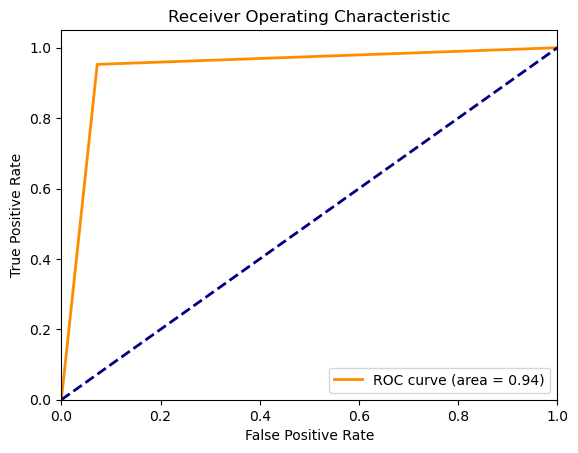

In [360]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [361]:
predictions = best_rf.predict(x_new_test)

In [362]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       955
           1       0.93      0.95      0.94       994

    accuracy                           0.94      1949
   macro avg       0.94      0.94      0.94      1949
weighted avg       0.94      0.94      0.94      1949



# Logistic Regression

In [363]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

In [364]:
lr = LogisticRegression(random_state=42, max_iter=10000)

In [365]:
param_dist = {
    'C': loguniform(1e-4, 1e4),
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['saga'],
    'l1_ratio': uniform(0, 1)
}

In [366]:
random_search = RandomizedSearchCV(estimator=lr, param_distributions=param_dist, n_iter=100, cv=5, verbose=2, n_jobs=-1, random_state=42)

In [367]:
random_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=10000,
                                                random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021CC67AF450>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021CC67AD690>,
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    'none'],
                                        'solver': ['saga']},
                   random_state=42, verbose=2)

In [368]:
best_params = random_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'C': 3.2077800037496047, 'l1_ratio': 0.6955160864261275, 'penalty': 'l1', 'solver': 'saga'}


In [369]:
best_lr = LogisticRegression(**best_params, random_state=42, max_iter=10000)

In [370]:
best_lr.fit(x_new_train, y_new_train)

LogisticRegression(C=3.2077800037496047, l1_ratio=0.6955160864261275,
                   max_iter=10000, penalty='l1', random_state=42,
                   solver='saga')

In [371]:
y_pred = best_lr.predict(x_new_test)

In [372]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [373]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [374]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [375]:
accuracy

0.8163160595177014

In [376]:
precision

0.8087378640776699

In [ ]:
recall

In [378]:
f1

0.8231225296442688

In [379]:
kappa

0.6322129778782333

In [380]:
specificity

0.793717277486911

In [381]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.8158727232504978


In [382]:
from sklearn.metrics import roc_curve, roc_auc_score

In [383]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

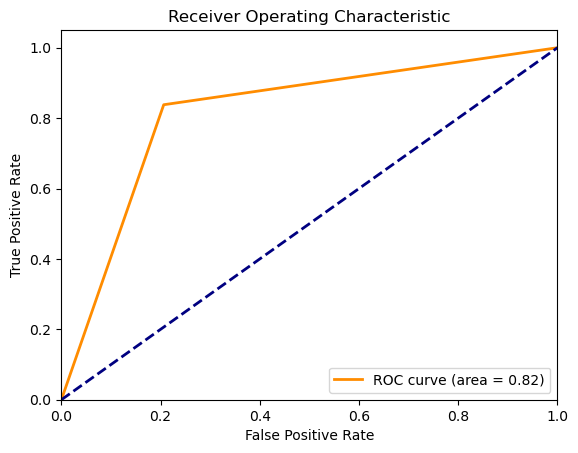

In [384]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [385]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [386]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81       955
           1       0.81      0.84      0.82       994

    accuracy                           0.82      1949
   macro avg       0.82      0.82      0.82      1949
weighted avg       0.82      0.82      0.82      1949



# Naive Bayes

In [387]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import classification_report

In [388]:
gnb = GaussianNB()

In [389]:
param_grid = {
    'var_smoothing': np.logspace(-12, 0, 50)
}

In [390]:
grid_search = GridSearchCV(estimator=gnb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': array([1.00000000e-12, 1.75751062e-12, 3.08884360e-12, 5.42867544e-12,
       9.54095476e-12, 1.67683294e-11, 2.94705170e-11, 5.17947468e-11,
       9.10298178e-11, 1.59985872e-10, 2.81176870e-10, 4.94171336e-10,
       8.68511374e-10, 1.52641797e-09, 2.68269580e-09, 4.71486636e-09,
       8.28642773e-09, 1.4563484...
       7.54312006e-07, 1.32571137e-06, 2.32995181e-06, 4.09491506e-06,
       7.19685673e-06, 1.26485522e-05, 2.22299648e-05, 3.90693994e-05,
       6.86648845e-05, 1.20679264e-04, 2.12095089e-04, 3.72759372e-04,
       6.55128557e-04, 1.15139540e-03, 2.02358965e-03, 3.55648031e-03,
       6.25055193e-03, 1.09854114e-02, 1.93069773e-02, 3.39322177e-02,
       5.96362332e-02, 1.04811313e-01, 1.84206997e-01, 3.23745754e-01,
       5.68986603e-01, 1.00000000e+00])},
             verbose=2)

In [391]:
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'var_smoothing': 0.059636233165946365}


In [392]:
best_gnb = GaussianNB(**best_params)
best_gnb.fit(x_new_train, y_new_train)
y_pred = best_gnb.predict(x_new_test)

In [394]:
y_pred = best_gnb.predict(x_new_test)

In [395]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [396]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [397]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [398]:
accuracy

0.7942534633145203

In [399]:
precision

0.7747914735866543

In [400]:
recall

0.8410462776659959

In [401]:
f1

0.8065605402797877

In [402]:
kappa

0.5876220501523566

In [403]:
specificity

0.7455497382198953

In [404]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.7932980079429456


In [405]:
from sklearn.metrics import roc_curve, roc_auc_score

In [406]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

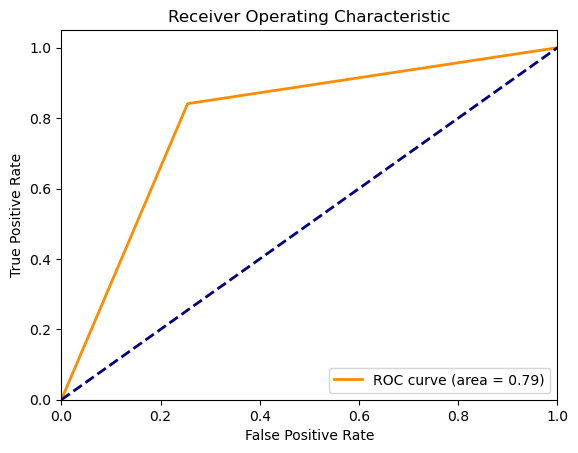

In [407]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [408]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.75      0.78       955
           1       0.77      0.84      0.81       994

    accuracy                           0.79      1949
   macro avg       0.80      0.79      0.79      1949
weighted avg       0.80      0.79      0.79      1949



# KNN

In [410]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import classification_report

In [411]:
knn_model = KNeighborsClassifier()

In [412]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [413]:
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_new_train, y_new_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [414]:
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [415]:
best_knn = grid_search.best_estimator_
accuracy = best_knn.score(x_new_test, y_new_test)
print("Test accuracy:", accuracy)

Test accuracy: 0.9687018984094408


In [419]:
y_pred = best_knn.predict(x_new_test)

In [420]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [421]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [422]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [423]:
accuracy

0.9687018984094408

In [424]:
precision

0.9697885196374623

In [425]:
recall

0.9688128772635815

In [426]:
f1

0.9693004529441369

In [427]:
kappa

0.9373800089435309

In [428]:
specificity

0.9685863874345549

In [429]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9686996323490682


In [430]:
from sklearn.metrics import roc_curve, roc_auc_score

In [431]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

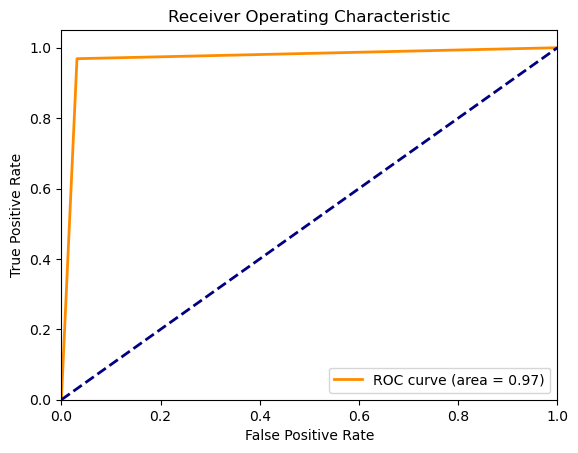

In [432]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [433]:
predictions = best_knn.predict(x_new_test)

In [434]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       955
           1       0.97      0.97      0.97       994

    accuracy                           0.97      1949
   macro avg       0.97      0.97      0.97      1949
weighted avg       0.97      0.97      0.97      1949



# Decision Tree

In [435]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import classification_report

In [436]:
dt_model = DecisionTreeClassifier(random_state=42)

In [437]:
param_grid = {
    'max_depth': list(np.arange(1, 21)),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [438]:
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_new_train, y_new_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [439]:
best_params = grid_search.best_params_
print("Best hyperparameers:", best_params)

Best hyperparameers: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [440]:
best_dt = grid_search.best_estimator_
accuracy = best_dt.score(x_new_test, y_new_test)
print("Test accuracy:", accuracy)

Test accuracy: 0.9153412006157003


In [441]:
y_pred = best_dt.predict(x_new_test)

In [442]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [443]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [444]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [445]:
accuracy

0.9153412006157003

In [446]:
precision

0.910802775024777

In [447]:
recall

0.9245472837022133

In [448]:
f1

0.9176235646530204

In [449]:
kappa

0.8305623684439305

In [450]:
specificity

0.9057591623036649

In [451]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9151532230029391


In [452]:
from sklearn.metrics import roc_curve, roc_auc_score

In [453]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

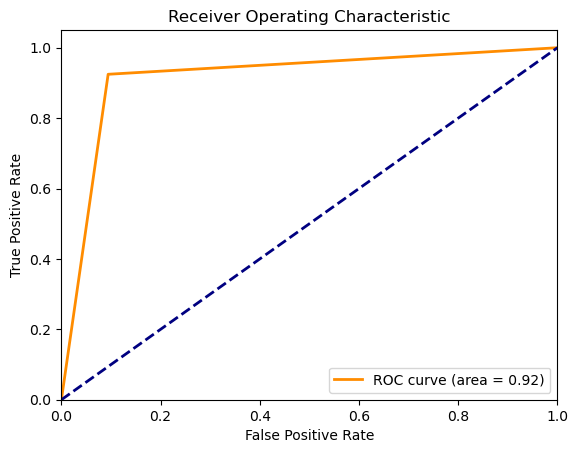

In [454]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [455]:
predictions = best_dt.predict(x_new_test)

In [456]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       955
           1       0.91      0.92      0.92       994

    accuracy                           0.92      1949
   macro avg       0.92      0.92      0.92      1949
weighted avg       0.92      0.92      0.92      1949



# XGBoost

In [457]:
import xgboost as xgb
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [458]:
xgb = XGBClassifier(random_state=42)

In [459]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

In [460]:
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 5184 candidates, totalling 25920 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'min_child_weight': [1, 2, 3],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.7, 0.8, 0.9]},
             verbose=2)

In [461]:
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}


In [462]:
best_xgb = XGBClassifier(**best_params, random_state=42)

In [463]:
best_xgb.fit(x_new_train, y_new_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [464]:
y_pred = best_xgb.predict(x_new_test)

In [465]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [466]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [467]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [468]:
accuracy

0.9343252950230888

In [469]:
precision

0.9295634920634921

In [470]:
recall

0.9426559356136821

In [471]:
f1

0.936063936063936

In [472]:
kappa

0.8685601745843243

In [473]:
specificity

0.9256544502617801

In [474]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.934155192937731


In [475]:
from sklearn.metrics import roc_curve, roc_auc_score

In [476]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

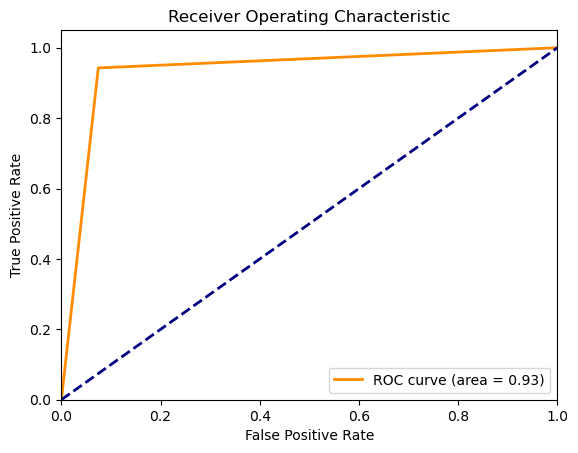

In [477]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [478]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       955
           1       0.93      0.94      0.94       994

    accuracy                           0.93      1949
   macro avg       0.93      0.93      0.93      1949
weighted avg       0.93      0.93      0.93      1949



# Gradient Boost

In [479]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [480]:
gbc = GradientBoostingClassifier(random_state=42)

In [481]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.7, 0.8]
}

In [482]:
grid_search = GridSearchCV(gbc, param_grid, cv=5, n_jobs=-1, verbose=2)

In [483]:
grid_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5, 6],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.6, 0.7, 0.8]},
             verbose=2)

In [484]:
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'learning_rate': 0.2, 'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 0.7}


In [485]:
best_gbc = GradientBoostingClassifier(**best_params, random_state=42)

In [486]:
best_gbc.fit(x_new_train, y_new_train)

GradientBoostingClassifier(learning_rate=0.2, max_depth=6, min_samples_leaf=4,
                           min_samples_split=10, n_estimators=300,
                           random_state=42, subsample=0.7)

In [487]:
y_pred = best_gbc.predict(x_new_test)

In [488]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [489]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [490]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [491]:
accuracy

0.9332991277578245

In [492]:
precision

0.9311377245508982

In [493]:
recall

0.9386317907444668

In [494]:
f1

0.9348697394789579

In [495]:
kappa

0.8665228834470886

In [496]:
specificity

0.9277486910994764

In [497]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9331902409219716


In [498]:
from sklearn.metrics import roc_curve, roc_auc_score

In [499]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

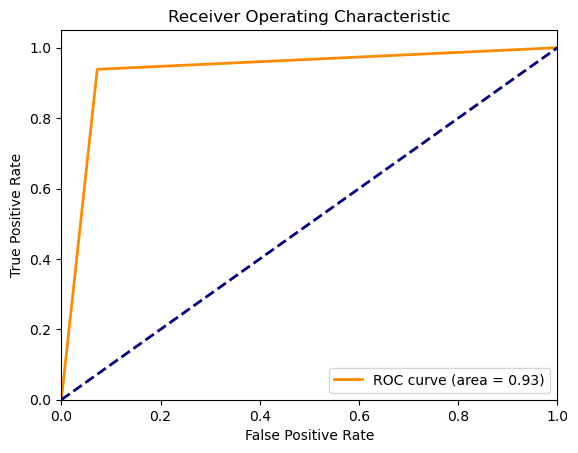

In [500]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [501]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       955
           1       0.93      0.94      0.93       994

    accuracy                           0.93      1949
   macro avg       0.93      0.93      0.93      1949
weighted avg       0.93      0.93      0.93      1949



In [502]:
predictions = best_gbc.predict(x_new_test)

In [503]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       955
           1       0.93      0.94      0.93       994

    accuracy                           0.93      1949
   macro avg       0.93      0.93      0.93      1949
weighted avg       0.93      0.93      0.93      1949



# MLP Classifier

In [504]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [505]:
mlp = MLPClassifier(random_state=42)

In [506]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['sgd', 'adam'],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01]
}

In [507]:
grid_search = GridSearchCV(mlp, param_grid, cv=5, n_jobs=-1, verbose=2)

In [508]:
grid_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=MLPClassifier(random_state=42), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh', 'logistic'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50),
                                                (100, 50)],
                         'learning_rate': ['constant', 'invscaling',
                                           'adaptive'],
                         'solver': ['sgd', 'adam']},
             verbose=2)

In [509]:
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'solver': 'adam'}


In [510]:
best_mlp = MLPClassifier(**best_params, random_state=42)

In [511]:
best_mlp.fit(x_new_train, y_new_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=(100, 50), random_state=42)

In [512]:
y_pred = best_mlp.predict(x_new_test)

In [513]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [514]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [515]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [516]:
accuracy

0.9286813750641355

In [517]:
precision

0.9601722282023681

In [518]:
recall

0.89738430583501

In [519]:
f1

0.9277171086843474

In [520]:
kappa

0.8574958904830162

In [521]:
specificity

0.9612565445026178

In [522]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9293204251688139


In [523]:
from sklearn.metrics import roc_curve, roc_auc_score

In [524]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

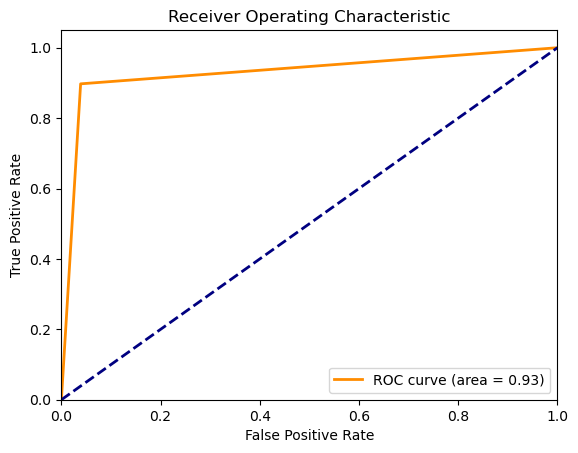

In [525]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [526]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       955
           1       0.96      0.90      0.93       994

    accuracy                           0.93      1949
   macro avg       0.93      0.93      0.93      1949
weighted avg       0.93      0.93      0.93      1949



In [527]:
predictions = best_mlp.predict(x_new_test)

In [528]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       955
           1       0.96      0.90      0.93       994

    accuracy                           0.93      1949
   macro avg       0.93      0.93      0.93      1949
weighted avg       0.93      0.93      0.93      1949



# Multinomial NB

In [529]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [530]:
mnb = MultinomialNB()

In [531]:
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]  
}

In [532]:
grid_search = GridSearchCV(estimator=mnb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [533]:
grid_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]}, verbose=2)

In [534]:
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'alpha': 0.1}


In [535]:
best_mnb = MultinomialNB(**best_params)

In [536]:
best_mnb.fit(x_new_train, y_new_train)

MultinomialNB(alpha=0.1)

In [537]:
y_pred = best_mnb.predict(x_new_test)

In [538]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [539]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [540]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [541]:
accuracy

0.7880964597229349

In [542]:
precision

0.7890547263681592

In [543]:
recall

0.7977867203219315

In [544]:
f1

0.7933966983491746

In [545]:
kappa

0.5759273298558409

In [546]:
specificity

0.7780104712041885

In [547]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.78789859576306


In [548]:
from sklearn.metrics import roc_curve, roc_auc_score

In [549]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

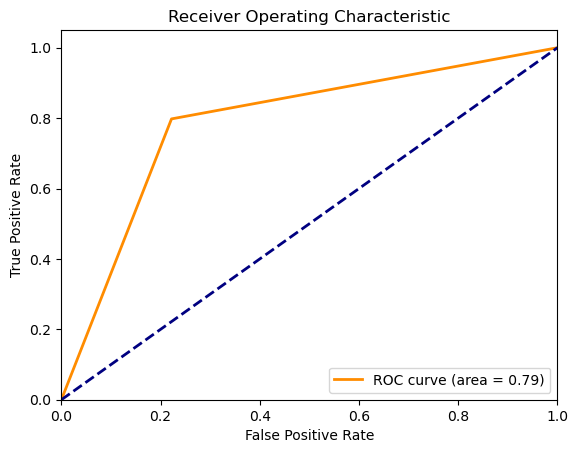

In [550]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [551]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78       955
           1       0.79      0.80      0.79       994

    accuracy                           0.79      1949
   macro avg       0.79      0.79      0.79      1949
weighted avg       0.79      0.79      0.79      1949



In [552]:
predictions = best_mnb.predict(x_new_test)

In [553]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.79      0.78      0.78       955
           1       0.79      0.80      0.79       994

    accuracy                           0.79      1949
   macro avg       0.79      0.79      0.79      1949
weighted avg       0.79      0.79      0.79      1949



# AdaBoostClassifier

In [554]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [555]:
ada = AdaBoostClassifier(random_state=42)

In [556]:
base_estimator = DecisionTreeClassifier(max_depth=1)

In [557]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

In [558]:
grid_search = GridSearchCV(estimator=ada, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [559]:
grid_search.fit(x_new_train, y_new_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200, 300]},
             verbose=2)

In [560]:
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'learning_rate': 1.0, 'n_estimators': 300}


In [561]:
best_ada = AdaBoostClassifier(**best_params, random_state=42)

In [562]:
best_ada.fit(x_new_train, y_new_train)

AdaBoostClassifier(n_estimators=300, random_state=42)

In [563]:
y_pred = best_ada.predict(x_new_test)

In [564]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [565]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [566]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [567]:
accuracy

0.8866085171883017

In [568]:
precision

0.8741529525653436

In [569]:
recall

0.9084507042253521

In [570]:
f1

0.8909718796250616

In [571]:
kappa

0.7729442878537326

In [572]:
specificity

0.8638743455497382

In [573]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.8861625248875451


In [574]:
from sklearn.metrics import roc_curve, roc_auc_score

In [575]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

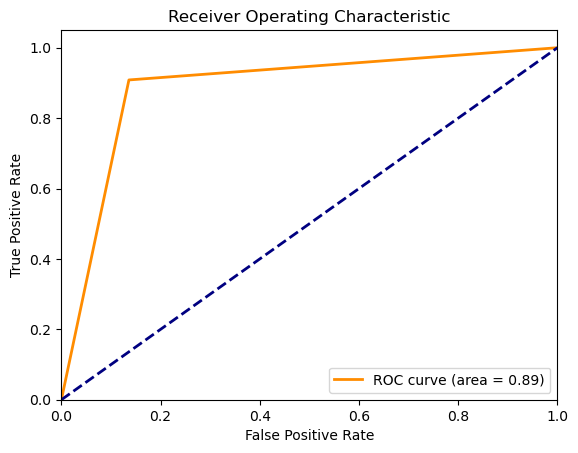

In [576]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [577]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       955
           1       0.87      0.91      0.89       994

    accuracy                           0.89      1949
   macro avg       0.89      0.89      0.89      1949
weighted avg       0.89      0.89      0.89      1949



In [578]:
predictions = best_ada.predict(x_new_test)

In [579]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       955
           1       0.87      0.91      0.89       994

    accuracy                           0.89      1949
   macro avg       0.89      0.89      0.89      1949
weighted avg       0.89      0.89      0.89      1949



# LightGBM

In [580]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [581]:
lgb_model = lgb.LGBMClassifier(random_state=42)

In [582]:
param_grid = {
    'num_leaves': [20, 30, 40],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

In [583]:
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_new_train, y_new_train)

best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 3976, number of negative: 3817
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 7793, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510201 -> initscore=0.040812
[LightGBM] [Info] Start training from score 0.040812
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 300, 'num_leaves': 40}


In [584]:
best_lgb_model = lgb.LGBMClassifier(**best_params, random_state=42)

In [585]:
best_lgb_model.fit(x_new_train, y_new_train)

[LightGBM] [Info] Number of positive: 3976, number of negative: 3817
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 7793, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510201 -> initscore=0.040812
[LightGBM] [Info] Start training from score 0.040812


LGBMClassifier(max_depth=15, n_estimators=300, num_leaves=40, random_state=42)

In [586]:
y_pred = best_lgb_model.predict(x_new_test)

In [587]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [588]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [589]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [590]:
accuracy

0.9374037968188815

In [591]:
precision

0.9299802761341223

In [592]:
recall

0.9486921529175051

In [593]:
f1

0.9392430278884463

In [594]:
kappa

0.874705969142568

In [595]:
specificity

0.9256544502617801

In [596]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9371733015896426


In [597]:
from sklearn.metrics import roc_curve, roc_auc_score

In [598]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

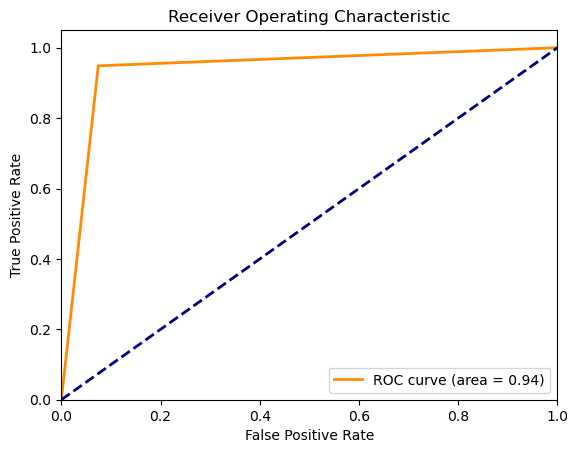

In [599]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [600]:
print("Classification Report:\n", classification_report(y_new_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       955
           1       0.93      0.95      0.94       994

    accuracy                           0.94      1949
   macro avg       0.94      0.94      0.94      1949
weighted avg       0.94      0.94      0.94      1949



In [601]:
predictions = best_lgb_model.predict(x_new_test)

In [602]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       955
           1       0.93      0.95      0.94       994

    accuracy                           0.94      1949
   macro avg       0.94      0.94      0.94      1949
weighted avg       0.94      0.94      0.94      1949



# CatBoost

In [603]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [604]:
catboost_model = CatBoostClassifier(random_seed=42, verbose=False)

In [605]:
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

In [606]:
grid_search = GridSearchCV(estimator=catboost_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_new_train, y_new_train)

best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best parameters found:  {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


In [607]:
best_catboost_model = CatBoostClassifier(**best_params, random_seed=42, verbose=False)

best_catboost_model.fit(x_new_train, y_new_train)

In [608]:
y_pred = best_catboost_model.predict(x_new_test)

In [609]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [610]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [611]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [612]:
accuracy

0.944073884043099

In [613]:
precision

0.9385530227948464

In [614]:
recall

0.9527162977867203

In [615]:
f1

0.945581627558662

In [616]:
kappa

0.8880684736993237

In [617]:
specificity

0.9350785340314136

In [618]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.943897415909067


In [619]:
from sklearn.metrics import roc_curve, roc_auc_score

In [620]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

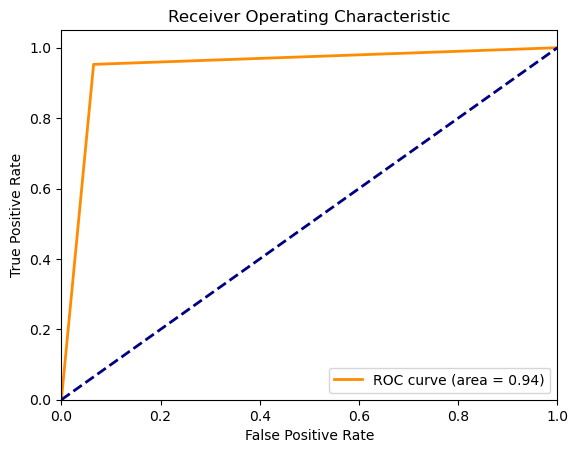

In [621]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [622]:
predictions = best_catboost_model.predict(x_new_test)

In [623]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       955
           1       0.94      0.95      0.95       994

    accuracy                           0.94      1949
   macro avg       0.94      0.94      0.94      1949
weighted avg       0.94      0.94      0.94      1949



# Stochastic Gradient Descent

In [624]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [625]:
sgd_model = SGDClassifier(random_state=42)

In [626]:
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'loss': ['hinge', 'log', 'modified_huber', 'squared_hinge', 'perceptron'],
    'penalty': ['l2', 'l1', 'elasticnet']
}

In [627]:
grid_search = GridSearchCV(estimator=sgd_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_new_train, y_new_train)

best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters found:  {'alpha': 0.01, 'loss': 'modified_huber', 'penalty': 'l2'}


In [628]:
best_sgd_model = SGDClassifier(**best_params, random_state=42)
best_sgd_model.fit(x_new_train, y_new_train)

y_pred = best_sgd_model.predict(x_new_test)

In [629]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [630]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [631]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [632]:
accuracy

0.8127244740892765

In [633]:
precision

0.7975402081362346

In [634]:
recall

0.8480885311871227

In [635]:
f1

0.8220380302291566

In [636]:
kappa

0.6248133652377033

In [637]:
specificity

0.7759162303664922

In [638]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.8120023807768074


In [639]:
from sklearn.metrics import roc_curve, roc_auc_score

In [640]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

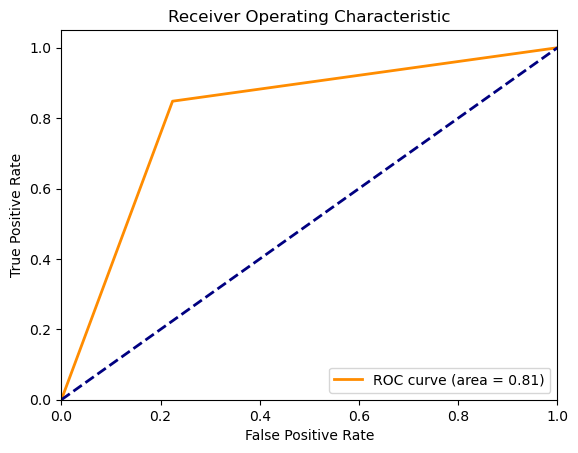

In [641]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [642]:
predictions = best_sgd_model.predict(x_new_test)

In [643]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       955
           1       0.80      0.85      0.82       994

    accuracy                           0.81      1949
   macro avg       0.81      0.81      0.81      1949
weighted avg       0.81      0.81      0.81      1949



# RidgeClassifier

In [88]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [89]:
ridge_model = RidgeClassifier(random_state=42)

In [90]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

In [91]:
grid_search = GridSearchCV(estimator=ridge_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_new_train, y_new_train)

best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found:  {'alpha': 1.0}


In [92]:
best_ridge_model = RidgeClassifier(**best_params, random_state=42)

best_ridge_model.fit(x_new_train, y_new_train)

y_pred = best_ridge_model.predict(x_new_test)

In [93]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [95]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [96]:
accuracy

0.8115942028985508

In [97]:
precision

0.7957089552238806

In [98]:
recall

0.8547094188376754

In [99]:
f1

0.8241545893719807

In [100]:
kappa

0.6218137075645003

In [101]:
specificity

0.765524625267666

In [102]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.8101170220526707


In [103]:
from sklearn.metrics import roc_curve, roc_auc_score

In [104]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

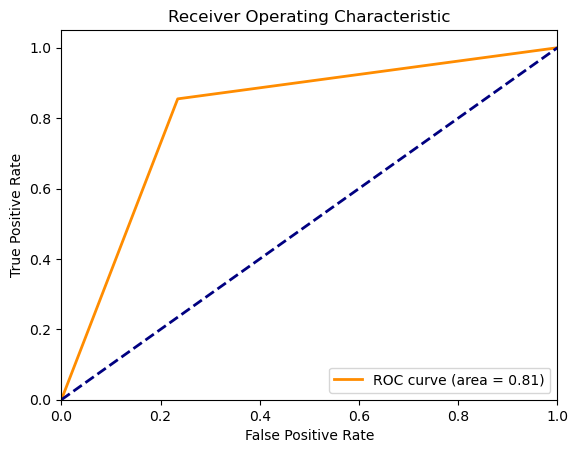

In [105]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [107]:
predictions = best_ridge_model.predict(x_new_test)

In [108]:
report = classification_report(y_new_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.77      0.80       934
           1       0.80      0.85      0.82       998

    accuracy                           0.81      1932
   macro avg       0.81      0.81      0.81      1932
weighted avg       0.81      0.81      0.81      1932



# ANN

In [109]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [110]:
model_ann = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [111]:
model_ann.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [112]:
model_ann.fit(x_new_train, y_new_train, epochs=2000, batch_size=32, validation_data=(x_new_test, y_new_test))

Epoch 1/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7484 - loss: 0.5206 - val_accuracy: 0.8157 - val_loss: 0.4023
Epoch 2/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8010 - loss: 0.4147 - val_accuracy: 0.8059 - val_loss: 0.3900
Epoch 3/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - loss: 0.4036 - val_accuracy: 0.8173 - val_loss: 0.3757
Epoch 4/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8207 - loss: 0.3896 - val_accuracy: 0.8323 - val_loss: 0.3773
Epoch 5/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8301 - loss: 0.3757 - val_accuracy: 0.8251 - val_loss: 0.3669
Epoch 6/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8325 - loss: 0.3688 - val_accuracy: 0.8359 - val_loss: 0.3564
Epoch 7/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8386 - loss: 0.3571 - val_accuracy: 0.8380 - val_loss: 0.3490
Epoch 8/2000
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8417 - loss: 0.3538 - 

In [114]:
y_pred = (model_ann.predict(x_new_test) > 0.5).astype("int32")
print(classification_report(y_new_test, y_pred))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       934
           1       0.94      0.93      0.94       998

    accuracy                           0.93      1932
   macro avg       0.93      0.93      0.93      1932
weighted avg       0.93      0.93      0.93      1932



In [115]:
def specificity_score(y_new_test, y_pred ):
    cm = confusion_matrix(y_new_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

In [116]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix

In [117]:
accuracy = accuracy_score(y_new_test, y_pred)
precision = precision_score(y_new_test, y_pred)
recall = recall_score(y_new_test, y_pred)
f1 = f1_score(y_new_test, y_pred)
kappa = cohen_kappa_score(y_new_test, y_pred)
specificity = specificity_score(y_new_test, y_pred)

In [118]:
accuracy

0.9347826086956522

In [119]:
precision

0.9421906693711968

In [120]:
recall

0.9308617234468938

In [121]:
f1

0.936491935483871

In [122]:
kappa

0.8694756980041093

In [123]:
specificity

0.9389721627408993

In [124]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_new_test, y_pred)
print("AUC: ", auc)

AUC:  0.9349169430938965


In [125]:
from sklearn.metrics import roc_curve, roc_auc_score

In [126]:
fpr, tpr, _ = roc_curve(y_new_test, y_pred)
auc = roc_auc_score(y_new_test, y_pred)

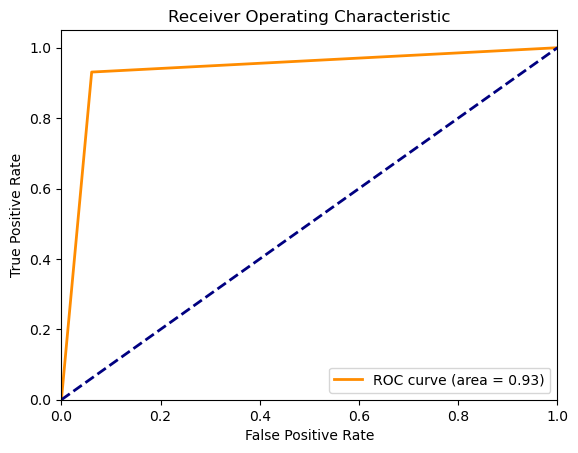

In [127]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()